<a href="https://colab.research.google.com/github/macontreras04/cpf/blob/main/Exam2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exam 2

Candidate CQF: Miguel Contreras \
Country: Mexico \
Cohort: JANUARY 2026


In [ ]:
import numpy as np
from numpy.random import randn
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
import random

import pandas as pd

## Mathematical framework

The Black-Scholes model assumes the stock price $S_{t}$ evolves in time according to the following stochastic differential equation (SDE):

$$dS_{t} = \mu S_{t}  dt +  \sigma S_{t} dW_{t}$$

where $dW_{t}$ is a standard Brownian motion, which means that is normal distributed $N(0,dt)$.


# Monte Carlo simulation

## Congruentional methods, Twister Mennser and Box-Muller Method.

Monte Carlo simulation is a technique widely used in option pricing because it is straightforward to implement and conceptually intuitive. At its core, it relies on simulating paths of stochastic processes—typically derived from stochastic differential equations (SDEs)—to estimate expected payoffs. These simulations require discretization of continuous-time dynamics, with the Euler–Maruyama scheme being one of the most common approaches due to its simplicity. A more refined alternative is the Milstein scheme, which incorporates an additional term accounting for the derivative of the diffusion coefficient, improving accuracy when modeling stochastic volatility or nonlinear diffusion.

Monte Carlo techniques were originally developed during Manhattan Project, where they were used to solve complex probabilistic problems in nuclear physics. Today, they are fundamental in quantitative finance, particularly in pricing derivatives and risk management.

A crucial component of any Monte Carlo simulation is the generation of high-quality pseudo-random numbers. Early methods such as Congruential methods (e.g., linear congruential generators) produce sequences of numbers using recursive modular arithmetic. While computationally efficient, they may suffer from periodicity and correlation issues if not carefully parameterized. More advanced generators like the Mersenne Twister provide extremely long periods and better statistical properties, making them standard in modern simulations. To transform uniformly distributed random numbers into normally distributed ones—essential for simulating Brownian motion—the Box–Muller transform is commonly used, converting pairs of uniform random variables into independent standard normal variables.

Finally, I is worth to mentioned that Python random generator engine is based on Twister Mennser.


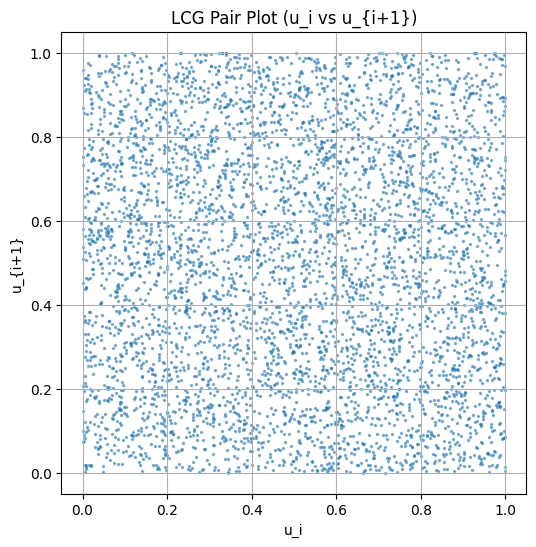

In [ ]:
# --- Linear Congruential Generator (LCG) ---
def lcg(n, seed=12345, a=1664525, c=1013904223, m=2**32):
    """
    Generate n pseudo-random numbers using an LCG.
    Returns numbers normalized to (0,1).
    """
    x = seed
    nums = []
    for _ in range(n):
        x = (a * x + c) % m
        nums.append(x / m)  # normalize
    return np.array(nums)

# --- Generate random numbers ---
n = 5000
u = lcg(n)

# --- Create pairs (u_i, u_{i+1}) ---
x = u[:-1]
y = u[1:]

# --- Plot ---
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=2, alpha=0.5)
plt.title("LCG Pair Plot (u_i vs u_{i+1})")
plt.xlabel("u_i")
plt.ylabel("u_{i+1}")
plt.grid(True)
plt.show()

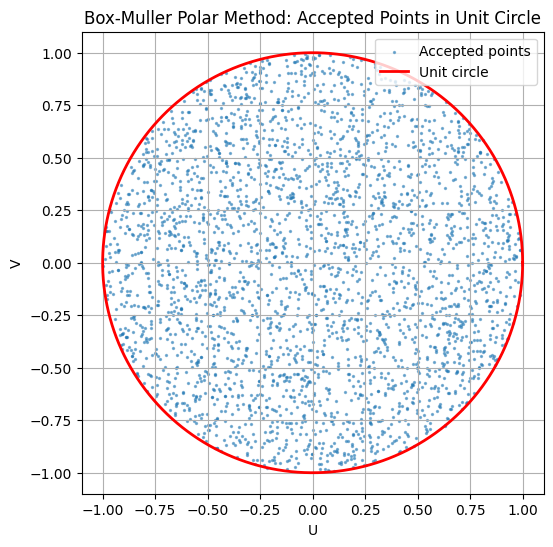

In [ ]:
# --- Polar Box-Muller (Marsaglia method) ---
def box_muller_polar(n):
    """
    Generate n standard normal random variables using the
    polar (rejection) form of Box-Muller.
    """
    z = []
    accepted_u = []
    accepted_v = []

    while len(z) < n:
        # Generate U, V ~ Uniform(-1, 1)
        u = np.random.uniform(-1, 1)
        v = np.random.uniform(-1, 1)
        s = u**2 + v**2

        # Accept only if inside unit circle
        if s > 0 and s < 1:
            factor = np.sqrt(-2 * np.log(s) / s)
            z.append(u * factor)   # one normal draw
            # store accepted points for visualization
            accepted_u.append(u)
            accepted_v.append(v)

    return np.array(z), np.array(accepted_u), np.array(accepted_v)

# --- Generate data ---
n = 3000
z, u_acc, v_acc = box_muller_polar(n)

# --- Plot 1: Unit circle acceptance ---
theta = np.linspace(0, 2*np.pi, 200)
circle_x = np.cos(theta)
circle_y = np.sin(theta)

plt.figure(figsize=(6,6))
plt.scatter(u_acc, v_acc, s=2, alpha=0.5, label="Accepted points")
plt.plot(circle_x, circle_y, 'r', linewidth=2, label="Unit circle")
plt.title("Box-Muller Polar Method: Accepted Points in Unit Circle")
plt.xlabel("U")
plt.ylabel("V")
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.show()

# Stochastic Differential Equation to model the stock behaviour

This methods uses discretization from a SDE to solving using Monte Carlo simulation. According to the non-arbitrage theory, we can change the SDE from the real probability measure $\mathbb{P}$ to $\mathbb{Q}$ making that $\mu$ is set equal to the risk-free rate $r$, associate to a risk-free instrument, typically a zero coupon bond. Therefore, the SDE under the real probability measure change as follows:

$$dS_{t} = \mu S_{t}  dt +  \sigma S_{t} dW^{\mathbb{P}} _{t}$$


Replacing $\mu$ by $r$


$$dS_{t} = r S_{t}  dt +  \sigma S_{t} dW^{\mathbb{Q}} _{t}$$

## Change of measure

As we saw on the lectures, it is possible using the right transformartion make a change of measure so the SDE above could become in a martingale. I f we compute the expectation replacing $S_{t}$ by the discounted price $S^{*}_{t}= S e^{-r(T-t) }$

$$dS^{*}_{t} = r S^{*}_{t}  dt +  \sigma S^{*} dW _{t}$$


$$d(S_{t} e^{-r(T-t)}) = (dS_{t})e^{-r(T-t)} - S_{t} r e^{-r(T-t)}$$

Now if we substitute $dS_{t}$:

$$d(S_{t} e^{-r(T-t)}) = ( r S_{t}  dt +  \sigma S dW) e^{-r(T-t)} - S_{t} r e^{-r(T-t)}$$


$$d(S_{t} e^{-r(T-t)}) = ( r S_{t} e^{-r(T-t)}  dt - S_{t} r e^{-r(T-t)} +  \sigma S_{t}  e^{-r(T-t)} dW)$$


$$dS^{*}_{t}  =  \sigma S^{*}_{t} dW _{t}$$

which implies the integral form

$$S_{t}^{*} = S_{t-1}^{*} + \int_{s}^{t}\sigma S_{u}^{*} dW_{u}^{\mathbb{Q}}$$


Take the conditional expectation with respect to $\mathcal{F}_s$

$$\mathbb{E}[S_{t}^{*}| \mathcal{F}_s]  = \mathbb{E}[S_{s}^{*} + \int_{s}^{t}\sigma S_{u}^{*} dW_{u}^{\mathbb{Q}}| \mathcal{F}_s ]$$

$$ = \mathbb{E}[S_{s}^{*}| \mathcal{F}_s ] + \mathbb{E}[ \int_{s}^{t}\sigma S_{u}^{*} dW_{u}^{\mathbb{Q}}| \mathcal{F}_s ]$$

Recaaling the second term is a Ito integral, the expectation is zero and applying "taking what is known" porperty we got:

$$ = \mathbb{E}[S_{t}^{*}| \mathcal{F}_s ] = S_{s}^{*}$$


The equation above is driftless and hece a martingale. Consequently, $\mathbb{E}[S_{t} e^{-r(T-t)} ] = S_{0}.$


# Euler-Maruyame scheme

The Euler–Maruyama scheme is the simplest and most widely used numerical method for approximating solutions of stochastic differential equations (SDEs). It is a direct stochastic extension of the classical Euler method for ordinary differential equations, obtained by discretizing time and simulating sample paths of the underlying stochastic process.

At each time step, the scheme updates the state variable using both the deterministic drift component and the stochastic diffusion term driven by increments of Brownian motion. Due to its straightforward implementation, the Euler–Maruyama method is often used as a baseline approach, although it provides only first-order accuracy in a weak sense and lower strong convergence compared to higher-order schemes such as Milstein.

For a GBM the Euler scheme is as follows:

For $t= 0,1,..,n$, $n$ large, simulate paths from the discrete version for $dt$ small

$$S_{t+1} = S_{t} + \mu S_{t}  dt +  \sigma S_{t} dW_{t} $$


Discounted mean: 100.09086192094155


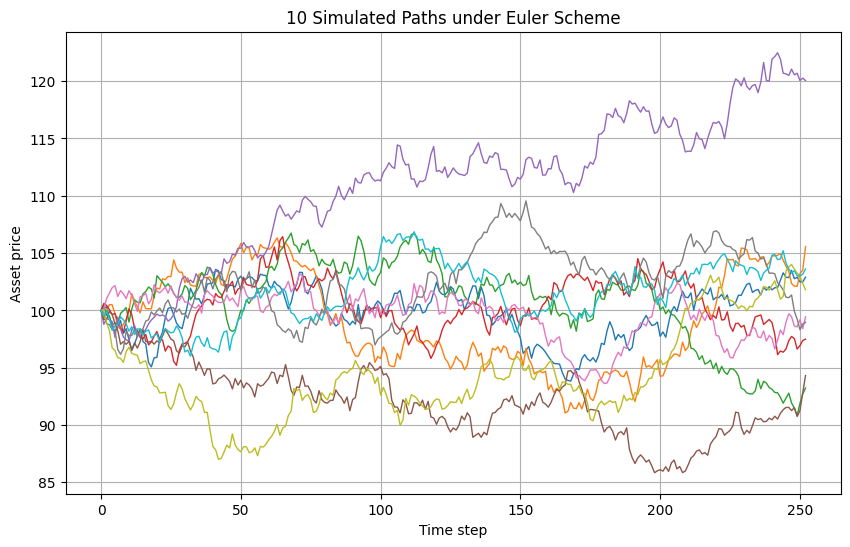

In [ ]:
# Simulation under Euler scheme

import numpy as np
import matplotlib.pyplot as plt


class EulerScheme:
    def __init__(
        self,
        s0=100,
        mu=0.03,
        sigma=0.1,
        steps=252,
        paths=10_000,
        dt=1 / 252,
        seed=42
    ):
        self.s0 = s0
        self.mu = mu
        self.sigma = sigma
        self.steps = steps
        self.paths = paths
        self.dt = dt
        self.T = steps * dt
        self.seed = seed

        self.rng = np.random.default_rng(seed)
        self.S = None

        self._validate()

    def _validate(self):
        if self.s0 <= 0:
            raise ValueError("s0 must be positive")
        if self.steps <= 0:
            raise ValueError("steps must be positive")
        if self.paths <= 0:
            raise ValueError("paths must be positive")
        if self.dt <= 0:
            raise ValueError("dt must be positive")
        if self.sigma < 0:
            raise ValueError("sigma must be non-negative")

    def simulate(self):
        z = self.rng.standard_normal((self.steps, self.paths))

        S = np.zeros((self.steps + 1, self.paths))
        S[0, :] = self.s0

        for i in range(1, self.steps + 1):
            S[i, :] = S[i - 1, :] * (
                1
                + self.mu * self.dt
                + self.sigma * np.sqrt(self.dt) * z[i - 1, :]
            )

        self.S = S
        return S

    def discounted_mean(self):
        if self.S is None:
            self.simulate()

        return np.mean(np.exp(-self.mu * self.T) * self.S[-1, :])

    def plot_paths(self, num_paths=10):
        if self.S is None:
            self.simulate()

        t = np.arange(self.steps + 1)

        plt.figure(figsize=(10, 6))
        for j in range(num_paths):
            plt.plot(t, self.S[:, j], linewidth=1)

        plt.title(f"{num_paths} Simulated Paths under Euler Scheme")
        plt.xlabel("Time step")
        plt.ylabel("Asset price")
        plt.grid(True)
        plt.show()


sim = EulerScheme(seed=42)

S = sim.simulate()

expected_val = sim.discounted_mean()
print("Discounted mean:", expected_val)

sim.plot_paths(num_paths=10)


# Milstein Scheme

The Milstein scheme is a higher-order numerical method for approximating solutions of stochastic differential equations (SDEs). Like the Euler–Maruyama method, it relies on time discretization and Monte Carlo simulation of sample paths; however, it achieves improved strong convergence by incorporating additional information from the diffusion term.

Specifically, the Milstein scheme extends the Euler approach by including a second-order correction term derived from the Itô–Taylor expansion. While the Euler scheme truncates after the first-order stochastic term, the Milstein method retains an extra term involving the derivative of the diffusion coefficient, leading to greater accuracy when simulating pathwise behavior.

For a GBM the Euler scheme is as follows:

For $t= 0,1,..,n$, $n$ large, simulate paths from the discrete version for $dt$ small

$$S_{t+1} = S_{t} + \mu S_{t}  dt +  \sigma S_{t} dW_{t} + \textcolor{blue}{\frac{1}{2}\sigma^{2} S_{t}(dW_{t}^2-dt)} $$




Discounted mean: 100.0908446792994


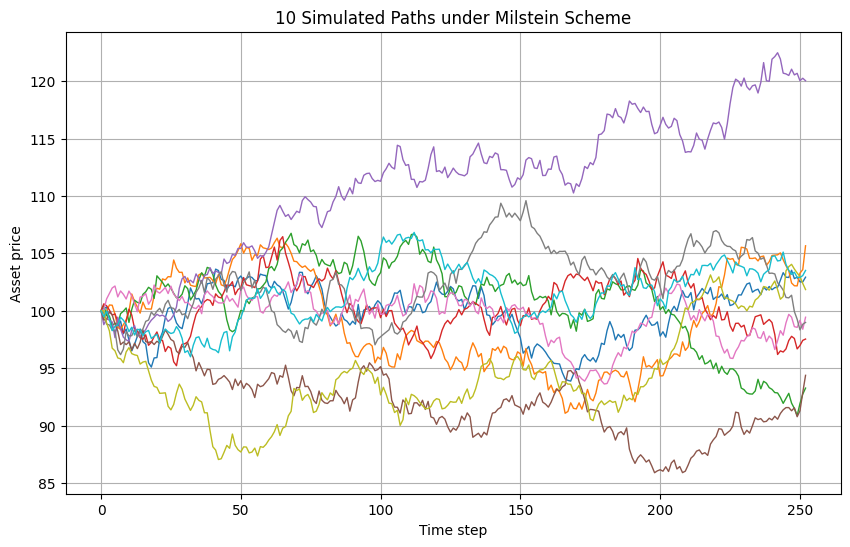

In [ ]:
# Simulation under Milstein scheme

class MilsteinScheme:
    def __init__(
        self,
        s0=100,
        mu=0.03,
        sigma=0.1,
        steps=252,
        paths=10_000,
        dt=1 / 252,
        seed=42
    ):
        self.s0 = s0
        self.mu = mu
        self.sigma = sigma
        self.steps = steps
        self.paths = paths
        self.dt = dt
        self.T = steps * dt
        self.seed = seed

        self.rng = np.random.default_rng(seed)
        self.S = None

        self._validate()

    def _validate(self):
        if self.s0 <= 0:
            raise ValueError("s0 must be positive")
        if self.steps <= 0:
            raise ValueError("steps must be positive")
        if self.paths <= 0:
            raise ValueError("paths must be positive")
        if self.dt <= 0:
            raise ValueError("dt must be positive")
        if self.sigma < 0:
            raise ValueError("sigma must be non-negative")

    def simulate(self):
        z = self.rng.standard_normal((self.steps, self.paths))

        S = np.zeros((self.steps + 1, self.paths))
        S[0, :] = self.s0

        for i in range(1, self.steps + 1):
            S_prev = S[i - 1, :]
            z_i = z[i - 1, :]

            S[i, :] = S_prev * (
                1
                + self.mu * self.dt
                + self.sigma * np.sqrt(self.dt) * z_i
                + 0.5 * self.sigma**2 * self.dt * (z_i**2 - 1)
            )

        self.S = S
        return S

    def discounted_mean(self):
        if self.S is None:
            self.simulate()

        return np.mean(np.exp(-self.mu * self.T) * self.S[-1, :])

    def plot_paths(self, num_paths=10):
        if self.S is None:
            self.simulate()

        t = np.arange(self.steps + 1)

        plt.figure(figsize=(10, 6))
        for j in range(num_paths):
            plt.plot(t, self.S[:, j], linewidth=1)

        plt.title(f"{num_paths} Simulated Paths under Milstein Scheme")
        plt.xlabel("Time step")
        plt.ylabel("Asset price")
        plt.grid(True)
        plt.show()


sim = MilsteinScheme(seed=42)

S = sim.simulate()

expected_val = sim.discounted_mean()
print("Discounted mean:", expected_val)

sim.plot_paths(num_paths=10)

## Explicit solution for the GBM SDE

We can apply Ito's Lemma to the SDE of the geometric Brownian motion to get an explicit soluction and simulate paths from there.
As we review on lectures, it is conveniente use the function $V= log (S)$. Furthermore, we have the following:

$$ V(S_{t}+dS_{t})= V(S_{t}) + \frac{dV}{dS_{t}}dS_{t}+ \frac{1}{2} \frac{d^{2}V}{dS^{2}_{t}}dS^{2}_{t}$$

Such equation becomes in

$$ dV=  \frac{dV}{dS_{t}}dS_{t}+ \frac{1}{2} \frac{d^{2}V}{dS^{2}_{t}} dS^{2}_{t}$$

Computing $dV$ and $d^{2}V/dS^{2}_{t}$

 $dV= 1/S$ and $d^{2}V/dS^{2}_{t}= -1/S^2$

Recalling the Ito multiplicatiopn table, if we unpacking $dS^{2}_{t}$ the expression with the terms $dt \cdot dW$,$ dt \cdot dt$ are equal to zero and $dW \cdot dW = dt$. Hence the result is $dS^{2}_{t} = \sigma^2 S^2_{t}dt $

Replacing $dV$ and $d^{2}V/dS^{2}_{t}$,

$$dV= \frac{1}{S_{t}}(\mu S_{t}  dt +  \sigma S_{t} dW)- \frac{1}{2} \sigma^2 S^2_{t}dt$$

Susbtitying $V= log(S)$

$$log(S_{t})= log(S_{t-1}) + (\mu  -  \frac{1}{2} \sigma^2 S^2_{t})d+\sigma S_{t} dW) $$


and applying the exponential both sides we got the following:

$$S_{t}=S_{t-1} e^{(\mu-\frac{1}{2} \sigma^{2})dt +\sigma dW  }$$



Discounted mean: 100.09103480308275


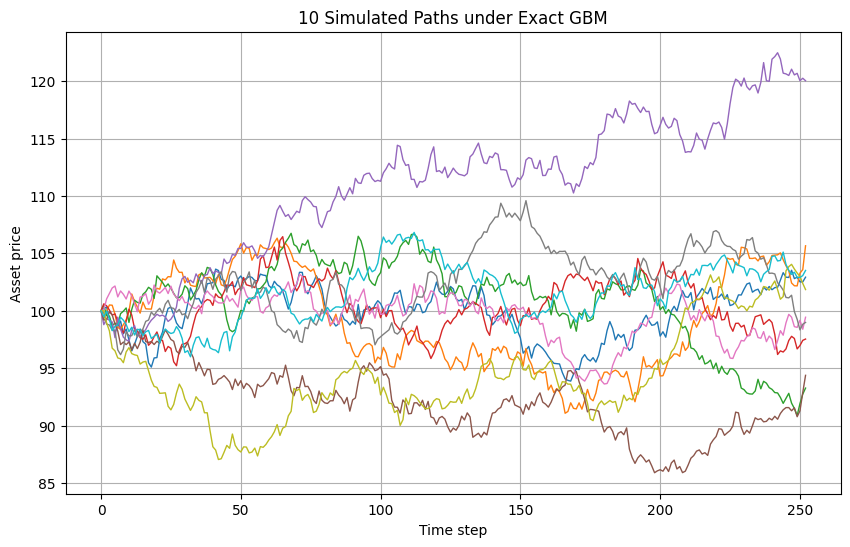

In [ ]:
# Simulation under explicit solution
class ExactGBMSimulator:
    def __init__(
        self,
        s0=100,
        mu=0.03,
        sigma=0.1,
        steps=252,
        paths=10_000,
        dt=1 / 252,
        seed=42
    ):
        self.s0 = s0
        self.mu = mu
        self.sigma = sigma
        self.steps = steps
        self.paths = paths
        self.dt = dt
        self.T = steps * dt
        self.seed = seed

        self.rng = np.random.default_rng(seed)
        self.S = None

        self._validate()

    def _validate(self):
        if self.s0 <= 0:
            raise ValueError("s0 must be positive")
        if self.steps <= 0:
            raise ValueError("steps must be positive")
        if self.paths <= 0:
            raise ValueError("paths must be positive")
        if self.dt <= 0:
            raise ValueError("dt must be positive")
        if self.sigma < 0:
            raise ValueError("sigma must be non-negative")

    def simulate(self):
        z = self.rng.standard_normal((self.steps, self.paths))

        S = np.zeros((self.steps + 1, self.paths))
        S[0, :] = self.s0

        drift = (self.mu - 0.5 * self.sigma**2) * self.dt
        diffusion = self.sigma * np.sqrt(self.dt)

        for i in range(1, self.steps + 1):
            S[i, :] = S[i - 1, :] * np.exp(
                drift + diffusion * z[i - 1, :]
            )

        self.S = S
        return S

    def discounted_mean(self):
        if self.S is None:
            self.simulate()

        return np.mean(np.exp(-self.mu * self.T) * self.S[-1, :])

    def plot_paths(self, num_paths=10):
        if self.S is None:
            self.simulate()

        t = np.arange(self.steps + 1)

        plt.figure(figsize=(10, 6))
        for j in range(num_paths):
            plt.plot(t, self.S[:, j], linewidth=1)

        plt.title(f"{num_paths} Simulated Paths under Exact GBM")
        plt.xlabel("Time step")
        plt.ylabel("Asset price")
        plt.grid(True)
        plt.show()


# usage
sim = ExactGBMSimulator(seed=42)

S = sim.simulate()

print("Discounted mean:", sim.discounted_mean())

sim.plot_paths(num_paths=10)

# Examining the price Option

Now we will perform an analysis of sentitvities on each model.


Comparison varying sigma
   sigma    Euler  Milstein    Exact
0    0.1   6.8755    6.8755   6.8765
1    0.2  10.5920   10.5930  10.5948
2    0.3  14.4561   14.4584  14.4610
3    0.4  18.3331   18.3362  18.3395


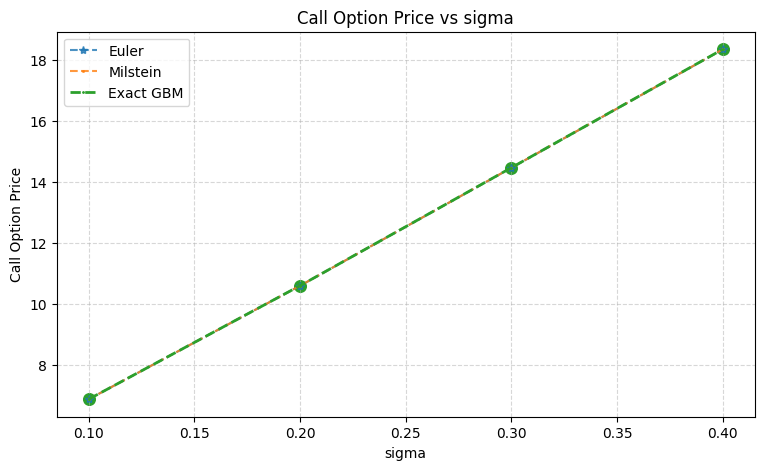


Comparison varying s0
    s0    Euler  Milstein    Exact
0   80   1.8940    1.8956   1.8966
1   90   5.1949    5.1968   5.1984
2  100  10.5920   10.5930  10.5948
3  110  17.8433   17.8419  17.8436
4  120  26.3977   26.3962  26.3976


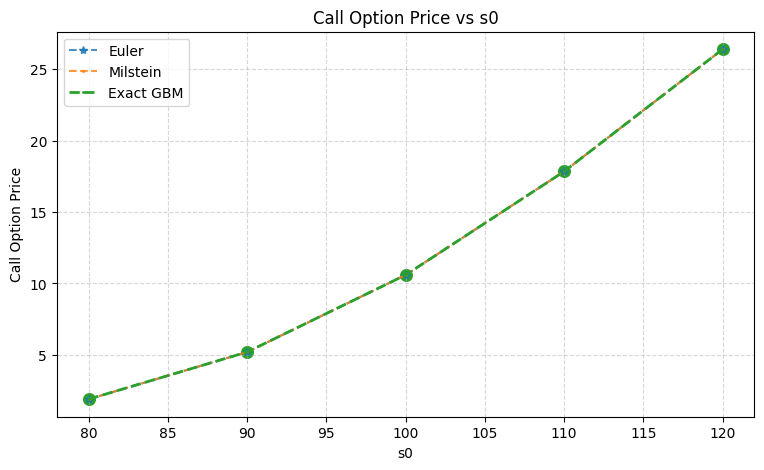


Comparison varying k
     k    Euler  Milstein    Exact
0   80  24.7824   24.7815  24.7826
1   90  16.8676   16.8664  16.8679
2  100  10.5920   10.5930  10.5948
3  110   6.1585    6.1608   6.1626
4  120   3.3122    3.3145   3.3160


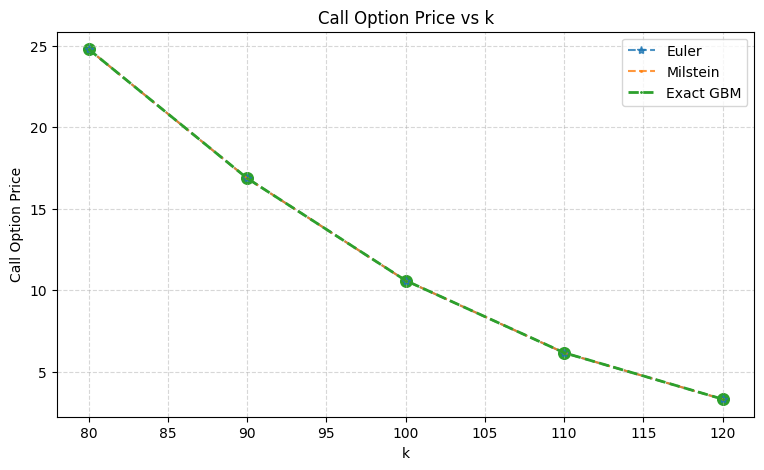


Comparison varying r
      r    Euler  Milstein    Exact
0  0.01   8.5728    8.5744   8.5747
1  0.03   9.5552    9.5563   9.5573
2  0.05  10.5920   10.5930  10.5948
3  0.07  11.6821   11.6822  11.6849
4  0.10  13.4150   13.4147  13.4188


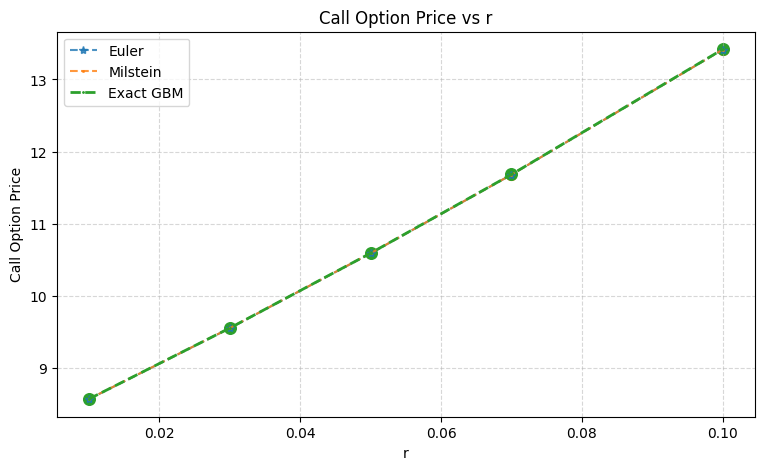


Comparison varying T
      T    Euler  Milstein    Exact
0  0.25   4.6815    4.6819   4.6821
1  0.50   6.9853    6.9861   6.9867
2  1.00  10.5920   10.5930  10.5948
3  1.50  13.6199   13.6207  13.6242
4  2.00  16.3350   16.3354  16.3408


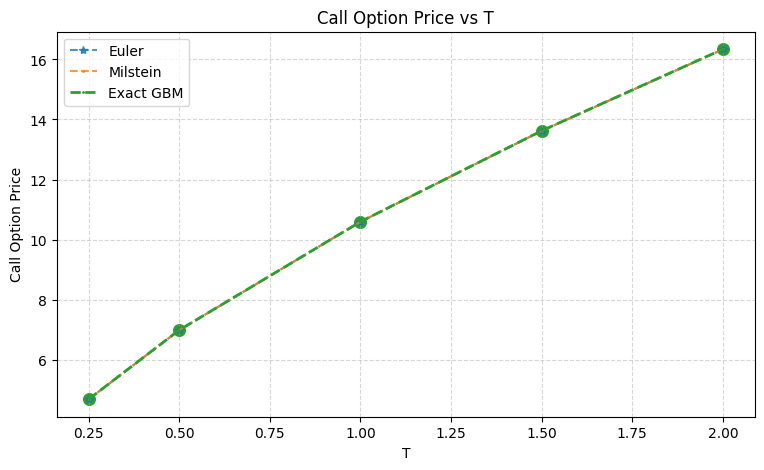

In [ ]:


class MC_OptionPricer:
    def __init__(self, s0=100, k=100, r=0.05, sigma=0.20,
                 T=1.0, paths=10_000, steps=252, seed=42):
        self.s0 = float(s0)
        self.k = float(k)
        self.r = float(r)
        self.sigma = float(sigma)
        self.T = float(T)
        self.paths = int(paths)
        self.steps = int(steps)
        self.dt = self.T / self.steps
        self.seed = seed

    def simulate(self, scheme):
        rng = np.random.default_rng(self.seed)
        z = rng.standard_normal((self.steps, self.paths))

        S = np.zeros((self.steps + 1, self.paths))
        S[0, :] = self.s0

        for i in range(1, self.steps + 1):
            z_i = z[i - 1, :]

            if scheme == "Euler":
                S[i, :] = S[i - 1, :] * (
                    1 + self.r * self.dt
                    + self.sigma * np.sqrt(self.dt) * z_i
                )

            elif scheme == "Milstein":
                S[i, :] = S[i - 1, :] * (
                    1 + self.r * self.dt
                    + self.sigma * np.sqrt(self.dt) * z_i
                    + 0.5 * self.sigma**2 * self.dt * (z_i**2 - 1)
                )

            elif scheme == "Exact":
                S[i, :] = S[i - 1, :] * np.exp(
                    (self.r - 0.5 * self.sigma**2) * self.dt
                    + self.sigma * np.sqrt(self.dt) * z_i
                )

            else:
                raise ValueError("scheme must be Euler, Milstein, or Exact")

        return S

    def call_price(self, scheme):
        S = self.simulate(scheme)
        payoff = np.maximum(S[-1, :] - self.k, 0)
        return np.exp(-self.r * self.T) * np.mean(payoff)


# ---------------------------
# Parameter sweep
# ---------------------------
def compare_parameter(parameter, values, base_params):
    rows = []

    for value in values:
        params = base_params.copy()
        params[parameter] = value

        pricer = MC_OptionPricer(**params)

        row = {
            parameter: value,
            "Euler": pricer.call_price("Euler"),
            "Milstein": pricer.call_price("Milstein"),
            "Exact": pricer.call_price("Exact")
        }

        rows.append(row)

    return pd.DataFrame(rows)


# ---------------------------
# Plots
# ---------------------------
def plot_comparison(df, parameter):
    plt.figure(figsize=(9, 5))

    plt.plot(
        df[parameter], df["Euler"],
        linestyle="--", marker="*", markersize=6,
        alpha=0.8, label="Euler"
    )

    plt.plot(
        df[parameter], df["Milstein"],
        linestyle="--", marker="s", markersize=1,
        alpha=0.8, label="Milstein"
    )

    plt.plot(
        df[parameter], df["Exact"],
        linestyle="--", marker="o", markersize=1,
        linewidth=2, label="Exact GBM"
    )

    # Optional: reinforce separation with scatter
    plt.scatter(df[parameter], df["Euler"], s=30)
    plt.scatter(df[parameter], df["Milstein"], s=50)
    plt.scatter(df[parameter], df["Exact"], s=70)

    plt.title(f"Call Option Price vs {parameter}")
    plt.xlabel(parameter)
    plt.ylabel("Call Option Price")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.show()


# ---------------------------
# Base parameters
# ---------------------------
base_params = {
    "s0": 100,
    "k": 100,
    "r": 0.05,
    "sigma": 0.20,
    "T": 1.0,
    "paths": 10_000,
    "steps": 252,
    "seed": 42
}


# ---------------------------
# Parameter sweeps
# ---------------------------
sweeps = {
    "sigma": [0.10, 0.20, 0.30, 0.40],
    "s0": [80, 90, 100, 110, 120],
    "k": [80, 90, 100, 110, 120],
    "r": [0.01, 0.03, 0.05, 0.07, 0.10],
    "T": [0.25, 0.50, 1.00, 1.50, 2.00]
}


# ---------------------------
# Run analysis
# ---------------------------
tables = {}

for parameter, values in sweeps.items():
    table = compare_parameter(parameter, values, base_params)
    tables[parameter] = table

    print(f"\nComparison varying {parameter}")
    print(table.round(4))

    plot_comparison(table, parameter)

As expected, the numerical results are consistent with standard option pricing theory. The option price increases monotonically with the underlying asset price $S$, reflecting the higher intrinsic value of a call option as it moves further in the money. A similar positive relationship is observed with respect to volatility $\sigma$, since options are convex payoffs and therefore benefit from increased uncertainty; in this sense, options can be viewed as instruments that are fundamentally sensitive to volatility.

An increase in the risk-free interest rate $r$ also leads to a higher call option price. This effect arises because the forward price of the underlying asset increases with $r$, effectively reducing the present value of the strike and making the option more valuable.

Furthermore, the option’s value can be decomposed into intrinsic value and time value. Longer maturities $T$ generally result in higher option prices, as they provide more opportunity for favorable price movements, thereby increasing the time value component.

Finally, the strike price $K$ exhibits the expected inverse relationship with the price of a call option: as K increases, the option becomes more out-of-the-money, reducing both its intrinsic value and its overall price.

The sensitivity analysis demonstrates a remarkable level of consistency across the Euler–Maruyama, Milstein, and exact Geometric Brownian Motion (GBM) solutions. For all parameter variations $(S,\sigma,K,r,T)$, the three methods produce nearly identical option prices, with discrepancies remaining on the order of $10^{−3}$ or smaller.

As volatility $\sigma$ increases from 0.1 to 0.4, all methods show a smooth and monotonic rise in option prices (e.g., from approximately 6.88 to 18.34), with Milstein and Euler closely tracking the exact solution, and Milstein consistently marginally closer. A similar pattern is observed when varying the initial asset price $S$, where option values increase from about 1.89 to 26.40, again with negligible differences across methods.

When varying the strike $K$, the expected inverse relationship is preserved, with prices decreasing from roughly 24.78 to 3.31 as the option moves further out-of-the-money. The three schemes remain tightly aligned, with only minimal numerical dispersion. Likewise, changes in the interest rate $r$ and maturity $T$ produce consistent upward shifts in option prices across all methods, reflecting standard theoretical sensitivities.

Overall, these results confirm that both Euler–Maruyama and Milstein provide highly accurate approximations of the exact GBM solution in this setting. While the Milstein scheme exhibits a slight edge in precision—consistent with its higher-order correction term—the differences are quantitatively negligible, reinforcing the robustness of all three approaches for sensitivity analysis.

# Applying antithetic variance to reduce variance

The antithetic variates technique is a classical variance reduction method in Monte Carlo methods, widely used to improve the efficiency of stochastic simulations without increasing the number of sampled paths.

The core idea is to exploit negative correlation by pairing each random draw with a carefully constructed “mirror” counterpart.

Suppose we have a Gaussian vector $v(z_{i})$ and also $v^{*}(z_{i})$. Then

$$Var[\frac{1}{2}(v(z_{i})+v^{*}(z_{i}))] < \frac{1}{2} Var[v(z_{i})] $$

which is equivalent to

$$Cov[v(z_{i}),v^{*}(z_{i})] < 0$$



──────────────────────────────────────────────────────────────
  CALL PRICING
──────────────────────────────────────────────────────────────
  Call — Standard MC                               10.490295
  Call — Standard MC 95% CI lo                     10.360746
  Call — Standard MC 95% CI hi                     10.619843
  Call — Antithetic MC                             10.467438
  Call — Antithetic MC 95% CI lo                   10.402787
  Call — Antithetic MC 95% CI hi                   10.532089
  Call — Black-Scholes                             10.450584
  Call abs error — Standard MC                      0.039711
  Call abs error — Antithetic MC                    0.016854

──────────────────────────────────────────────────────────────
  PUT PRICING
──────────────────────────────────────────────────────────────
  Put — Antithetic MC                               5.581405
  Put — Antithetic MC 95% CI lo                     5.540206
  Put — Antithetic MC 95% CI hi               

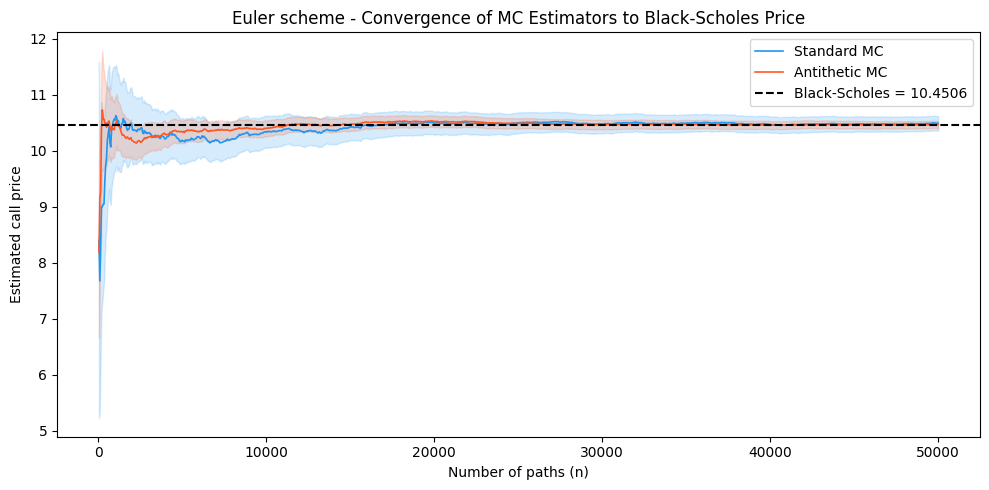

In [ ]:
"""
Euler-Maruyama Monte Carlo Option Pricer with Antithetic Variates
=================================================================
Prices European call and put options under GBM using the
Euler-Maruyama scheme.

The Euler update in linear space is:

    S(t+dt) = S(t) + r*S(t)*dt + sigma*S(t)*dW

This introduces an O(dt) discretisation bias (unlike the exact
log-space solution), so a sufficient number of time steps m is
needed to keep the bias small.

Usage
-----
    pricer = EulerMC(S0=100, K=100, r=0.05, sigma=0.20, T=1, m=252, n=50_000)
    pricer.run()
    pricer.print_results()
    pricer.plot()
"""

import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


class EulerMC:
    """
    European option pricer using the Euler-Maruyama scheme with antithetic variates.

    Parameters
    ----------
    S0    : Initial stock price.
    K     : Strike price.
    r     : Risk-free rate (annualised, continuously compounded).
    sigma : Volatility (annualised).
    T     : Time to expiry in years.
    m     : Number of time steps per path (more steps = less discretisation bias).
    n     : Number of Monte Carlo paths.
    seed  : Random seed for reproducibility.
    """

    def __init__(self, S0, K, r, sigma, T, m, n, seed=42):
        if S0 <= 0 or K <= 0:
            raise ValueError("S0 and K must be positive.")
        if sigma <= 0 or T <= 0:
            raise ValueError("sigma and T must be positive.")

        self.S0    = S0
        self.K     = K
        self.r     = r
        self.sigma = sigma
        self.T     = T
        self.m     = m
        self.n     = n
        self.seed  = seed
        self.dt    = T / m

        # Populated by .run()
        self.results         = None
        self.disc_payoff_std = None
        self.disc_payoff_av  = None
        self.disc_stock_av   = None

    # ------------------------------------------------------------------
    # Black-Scholes benchmarks
    # ------------------------------------------------------------------

    def _bs_call(self):
        """Closed-form Black-Scholes call price."""
        d1 = (np.log(self.S0 / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) \
             / (self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma * np.sqrt(self.T)
        return self.S0 * norm.cdf(d1) - self.K * np.exp(-self.r * self.T) * norm.cdf(d2)

    def _bs_put(self):
        """Black-Scholes put price via put-call parity."""
        return self._bs_call() - self.S0 + self.K * np.exp(-self.r * self.T)

    # ------------------------------------------------------------------
    # Simulation
    # ------------------------------------------------------------------

    def _simulate(self):
        """
        Simulate terminal GBM stock prices via the Euler-Maruyama scheme.

        Update rule at each step:

            S(t+dt) = S(t) + r*S(t)*dt + sigma*S(t)*sqrt(dt)*Z

        All (m x n) noise is drawn at once. The time-step loop iterates
        over m rows of Z, but each step is a fully vectorised operation
        across all n paths simultaneously.

        Returns both standard and antithetic terminal prices, shape (2, n).
        """
        rng     = np.random.default_rng(self.seed)
        Z       = rng.standard_normal((self.m, self.n))   # (m, n)
        sqrt_dt = np.sqrt(self.dt)

        S_std  = np.full(self.n, self.S0, dtype=float)
        S_anti = np.full(self.n, self.S0, dtype=float)

        for i in range(self.m):
            dW     = sqrt_dt * Z[i]                        # (n,)
            S_std  = S_std  + self.r * S_std  * self.dt + self.sigma * S_std  * dW
            S_anti = S_anti + self.r * S_anti * self.dt - self.sigma * S_anti * dW

        return np.stack([S_std, S_anti])                   # (2, n)

    # ------------------------------------------------------------------
    # Payoffs
    # ------------------------------------------------------------------

    def _call_payoff(self, S):
        return np.maximum(S - self.K, 0.0)

    def _put_payoff(self, S):
        return np.maximum(self.K - S, 0.0)

    # ------------------------------------------------------------------
    # Confidence interval
    # ------------------------------------------------------------------

    def _mean_and_ci(self, samples, level=0.95):
        """Return (mean, lower, upper) using the Normal CLT approximation."""
        mu = float(np.mean(samples))
        se = float(np.std(samples, ddof=1)) / np.sqrt(len(samples))
        z  = norm.ppf(0.5 + level / 2)
        return mu, mu - z * se, mu + z * se

    # ------------------------------------------------------------------
    # Public interface
    # ------------------------------------------------------------------

    def run(self):
        """Run the full simulation and store all pricing + variance metrics."""
        discount = np.exp(-self.r * self.T)
        S        = self._simulate()              # (2, n)

        # Discounted payoffs for both path rows
        dp_call  = discount * self._call_payoff(S)   # (2, n)
        dp_put   = discount * self._put_payoff(S)    # (2, n)
        dp_stock = discount * S                      # (2, n)

        # Standard MC  — row 0 only
        self.disc_payoff_std = dp_call[0]

        # Antithetic estimator — average each pair before averaging over n
        self.disc_payoff_av = 0.5 * (dp_call[0]  + dp_call[1])
        self.disc_stock_av  = 0.5 * (dp_stock[0] + dp_stock[1])
        disc_put_av         = 0.5 * (dp_put[0]   + dp_put[1])

        # Black-Scholes
        bs_call = self._bs_call()
        bs_put  = self._bs_put()

        # Prices + CIs
        p_std, ci_std_lo, ci_std_hi = self._mean_and_ci(self.disc_payoff_std)
        p_av,  ci_av_lo,  ci_av_hi  = self._mean_and_ci(self.disc_payoff_av)
        p_put, ci_put_lo, ci_put_hi = self._mean_and_ci(disc_put_av)

        # Variance helpers
        def var_est(x):
            return float(np.var(x, ddof=1)) / self.n

        def corr(a, b):
            return float(np.corrcoef(a, b)[0, 1])

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            payoff_ratio = var_est(self.disc_payoff_std) / var_est(self.disc_payoff_av)
            stock_ratio  = var_est(dp_stock[0]) / var_est(self.disc_stock_av)

        self.results = {
            # Call
            "Call — Standard MC":               p_std,
            "Call — Standard MC 95% CI lo":     ci_std_lo,
            "Call — Standard MC 95% CI hi":     ci_std_hi,
            "Call — Antithetic MC":             p_av,
            "Call — Antithetic MC 95% CI lo":   ci_av_lo,
            "Call — Antithetic MC 95% CI hi":   ci_av_hi,
            "Call — Black-Scholes":             bs_call,
            "Call abs error — Standard MC":     abs(p_std - bs_call),
            "Call abs error — Antithetic MC":   abs(p_av  - bs_call),
            # Put
            "Put — Antithetic MC":              p_put,
            "Put — Antithetic MC 95% CI lo":    ci_put_lo,
            "Put — Antithetic MC 95% CI hi":    ci_put_hi,
            "Put — Black-Scholes":              bs_put,
            "Put abs error — Antithetic MC":    abs(p_put - bs_put),
            # Variance reduction
            "Var(estimator) — Standard MC":     var_est(self.disc_payoff_std),
            "Var(estimator) — Antithetic MC":   var_est(self.disc_payoff_av),
            "Payoff variance reduction ratio":  payoff_ratio,
            "Corr(payoff+, payoff-)":           corr(dp_call[0], dp_call[1]),
            # Martingale check
            "E[disc. stock] — Standard MC":     float(np.mean(dp_stock[0])),
            "E[disc. stock] — Antithetic MC":   float(np.mean(self.disc_stock_av)),
            "Stock variance reduction ratio":   stock_ratio,
            "Corr(stock+, stock-)":             corr(dp_stock[0], dp_stock[1]),
        }
        return self

    def print_results(self):
        """Print results grouped into labelled sections."""
        if self.results is None:
            raise RuntimeError("Call .run() first.")

        sections = [
            ("CALL PRICING", [
                "Call — Standard MC",
                "Call — Standard MC 95% CI lo",
                "Call — Standard MC 95% CI hi",
                "Call — Antithetic MC",
                "Call — Antithetic MC 95% CI lo",
                "Call — Antithetic MC 95% CI hi",
                "Call — Black-Scholes",
                "Call abs error — Standard MC",
                "Call abs error — Antithetic MC",
            ]),
            ("PUT PRICING", [
                "Put — Antithetic MC",
                "Put — Antithetic MC 95% CI lo",
                "Put — Antithetic MC 95% CI hi",
                "Put — Black-Scholes",
                "Put abs error — Antithetic MC",
            ]),
            ("VARIANCE REDUCTION", [
                "Var(estimator) — Standard MC",
                "Var(estimator) — Antithetic MC",
                "Payoff variance reduction ratio",
                "Corr(payoff+, payoff-)",
            ]),
            ("MARTINGALE CHECK  (E[e^{-rT} S_T] should equal S0)", [
                "E[disc. stock] — Standard MC",
                "E[disc. stock] — Antithetic MC",
                "Stock variance reduction ratio",
                "Corr(stock+, stock-)",
            ]),
        ]

        col_w = 44
        for title, keys in sections:
            print(f"\n{'─' * 62}")
            print(f"  {title}")
            print(f"{'─' * 62}")
            for k in keys:
                print(f"  {k:<{col_w}}  {self.results[k]:>12.6f}")
        print(f"\n{'─' * 62}\n")

    def plot(self):
        """Produce convergence + distribution plots."""
        if self.results is None:
            raise RuntimeError("Call .run() first.")

        self._plot_convergence()
        #self._plot_histogram(
        #    self.disc_payoff_av,
        #    vlines=[
        #        (self.results["Call — Antithetic MC"],
        #         f"Antithetic MC = {self.results['Call — Antithetic MC']:.4f}", "-"),
        #        (self.results["Call — Black-Scholes"],
        #         f"Black-Scholes = {self.results['Call — Black-Scholes']:.4f}", "--"),
        #    ],
        #    xlabel="Discounted terminal payoff",
        #    title="Antithetic MC: Discounted Call Payoff Distribution",
        #)
        #self._plot_histogram(
        #    self.disc_stock_av,
        #    vlines=[
        #        (self.results["E[disc. stock] — Antithetic MC"],
        #         f"MC mean = {self.results['E[disc. stock] — Antithetic MC']:.4f}", "-"),
        #        (self.S0, f"S₀ = {self.S0:.4f}  (martingale target)", "--"),
        #    ],
        #    xlabel="Discounted terminal stock value",
        #    title="Antithetic MC: Discounted Stock Value Distribution",
        #)

    # ------------------------------------------------------------------
    # Private plot helpers
    # ------------------------------------------------------------------

    def _plot_convergence(self):
        bs  = self.results["Call — Black-Scholes"]
        ns  = np.arange(1, self.n + 1)
        z95 = norm.ppf(0.975)

        def running_stats(samples):
            cum    = np.cumsum(samples)
            mean   = cum / ns
            cum_sq = np.cumsum(samples ** 2)
            with np.errstate(invalid="ignore"):
                var = np.where(ns > 1, (cum_sq - cum**2 / ns) / (ns - 1), 0.0)
            se = np.sqrt(np.maximum(var, 0.0) / ns)
            return mean, mean - z95 * se, mean + z95 * se

        step = max(1, self.n // 1000)
        idx  = np.arange(step - 1, self.n, step)

        ms, ls, hs = running_stats(self.disc_payoff_std)
        ma, la, ha = running_stats(self.disc_payoff_av)

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(ns[idx], ms[idx], color="#2196F3", linewidth=1.2, label="Standard MC")
        ax.fill_between(ns[idx], ls[idx], hs[idx], color="#2196F3", alpha=0.18)
        ax.plot(ns[idx], ma[idx], color="#FF5722", linewidth=1.2, label="Antithetic MC")
        ax.fill_between(ns[idx], la[idx], ha[idx], color="#FF5722", alpha=0.18)
        ax.axhline(bs, color="black", linestyle="--", linewidth=1.5,
                   label=f"Black-Scholes = {bs:.4f}")
        ax.set_xlabel("Number of paths (n)")
        ax.set_ylabel("Estimated call price")
        ax.set_title("Euler scheme - Convergence of MC Estimators to Black-Scholes Price")
        ax.legend()
        plt.tight_layout()
        plt.show()

    def _plot_histogram(self, data, vlines, xlabel, title):
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.hist(data, bins=60, alpha=0.75, edgecolor="black", linewidth=0.4)
        for value, label, style in vlines:
            ax.axvline(value, linewidth=2, linestyle=style, label=label)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Frequency")
        ax.set_title(title)
        ax.legend()
        plt.tight_layout()
        plt.show()


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    pricer = EulerMC(
        S0=100, K=100, r=0.05, sigma=0.20,
        T=1, m=252, n=50_000, seed=42,
    )
    pricer.run()
    pricer.print_results()
    pricer.plot()


──────────────────────────────────────────────────────────────
  CALL PRICING
──────────────────────────────────────────────────────────────
  Call — Standard MC                               10.489837
  Call — Standard MC 95% CI lo                     10.360212
  Call — Standard MC 95% CI hi                     10.619461
  Call — Antithetic MC                             10.467480
  Call — Antithetic MC 95% CI lo                   10.402757
  Call — Antithetic MC 95% CI hi                   10.532204
  Call — Black-Scholes                             10.450584
  Call abs error — Standard MC                      0.039253
  Call abs error — Antithetic MC                    0.016897

──────────────────────────────────────────────────────────────
  PUT PRICING
──────────────────────────────────────────────────────────────
  Put — Antithetic MC                               5.581691
  Put — Antithetic MC 95% CI lo                     5.540522
  Put — Antithetic MC 95% CI hi               

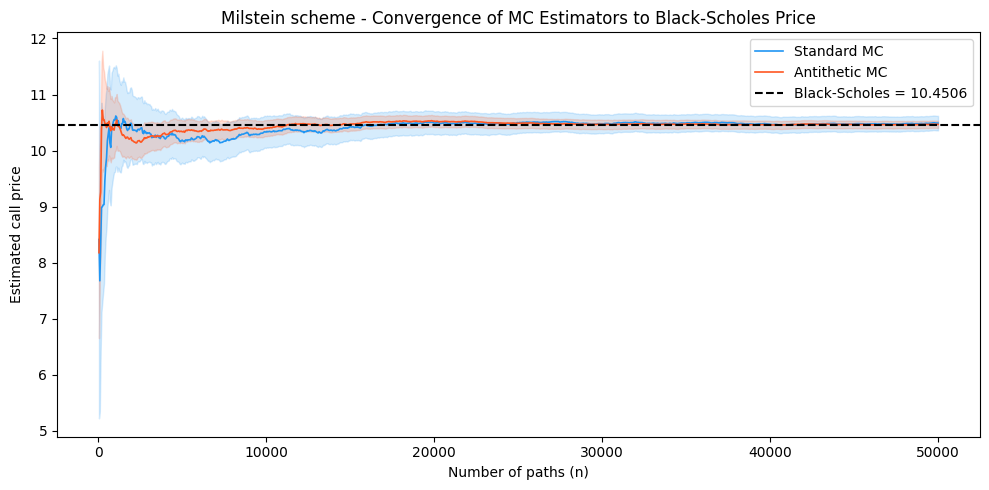

In [ ]:
"""
Milstein Monte Carlo Option Pricer with Antithetic Variates
============================================================
Prices European call and put options under GBM using the exact
log-space Milstein scheme.

Usage
-----
    pricer = MilsteinMC(S0=100, K=100, r=0.05, sigma=0.20, T=1, m=252, n=50_000)
    pricer.run()
    pricer.print_results()
    pricer.plot()
"""

import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


class MilsteinMC:
    """
    European option pricer using the Milstein scheme with antithetic variates.

    Parameters
    ----------
    S0    : Initial stock price.
    K     : Strike price.
    r     : Risk-free rate (annualised, continuously compounded).
    sigma : Volatility (annualised).
    T     : Time to expiry in years.
    m     : Number of time steps per path.
    n     : Number of Monte Carlo paths.
    seed  : Random seed for reproducibility.
    """

    def __init__(self, S0, K, r, sigma, T, m, n, seed=42):
        if S0 <= 0 or K <= 0:
            raise ValueError("S0 and K must be positive.")
        if sigma <= 0 or T <= 0:
            raise ValueError("sigma and T must be positive.")

        self.S0    = S0
        self.K     = K
        self.r     = r
        self.sigma = sigma
        self.T     = T
        self.m     = m
        self.n     = n
        self.seed  = seed
        self.dt    = T / m

        # Populated by .run()
        self.results         = None
        self.disc_payoff_std = None
        self.disc_payoff_av  = None
        self.disc_stock_av   = None

    # ------------------------------------------------------------------
    # Black-Scholes benchmarks
    # ------------------------------------------------------------------

    def _bs_call(self):
        """Closed-form Black-Scholes call price."""
        d1 = (np.log(self.S0 / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) \
             / (self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma * np.sqrt(self.T)
        return self.S0 * norm.cdf(d1) - self.K * np.exp(-self.r * self.T) * norm.cdf(d2)

    def _bs_put(self):
        """Black-Scholes put price via put-call parity."""
        return self._bs_call() - self.S0 + self.K * np.exp(-self.r * self.T)

    # ------------------------------------------------------------------
    # Simulation
    # ------------------------------------------------------------------

    def _simulate(self):
        """
        Simulate terminal GBM stock prices (log-space, exact solution).

            log S(T) = log S0 + (r - 0.5*sigma^2)*T + sigma*sqrt(dt)*sum(Z)

        All (m x n) noise drawn at once — no Python loop over time steps.
        Returns both standard and antithetic terminal prices, shape (2, n).
        """
        rng   = np.random.default_rng(self.seed)
        Z     = rng.standard_normal((self.m, self.n))
        drift = (self.r - 0.5 * self.sigma**2) * self.dt
        vol   = self.sigma * np.sqrt(self.dt)
        log_S0 = np.log(self.S0)

        S_std  = np.exp(log_S0 + (drift + vol *  Z).sum(axis=0))
        S_anti = np.exp(log_S0 + (drift + vol * -Z).sum(axis=0))
        return np.stack([S_std, S_anti])   # (2, n)

    # ------------------------------------------------------------------
    # Payoffs
    # ------------------------------------------------------------------

    def _call_payoff(self, S):
        return np.maximum(S - self.K, 0.0)

    def _put_payoff(self, S):
        return np.maximum(self.K - S, 0.0)

    # ------------------------------------------------------------------
    # Confidence interval
    # ------------------------------------------------------------------

    def _mean_and_ci(self, samples, level=0.95):
        """Return (mean, lower, upper) using the Normal CLT approximation."""
        mu = float(np.mean(samples))
        se = float(np.std(samples, ddof=1)) / np.sqrt(len(samples))
        z  = norm.ppf(0.5 + level / 2)
        return mu, mu - z * se, mu + z * se

    # ------------------------------------------------------------------
    # Public interface
    # ------------------------------------------------------------------

    def run(self):
        """Run the full simulation and store all pricing + variance metrics."""
        discount = np.exp(-self.r * self.T)
        S        = self._simulate()              # (2, n)

        # Discounted payoffs for both path rows
        dp_call  = discount * self._call_payoff(S)   # (2, n)
        dp_put   = discount * self._put_payoff(S)    # (2, n)
        dp_stock = discount * S                      # (2, n)

        # Standard MC  — row 0 only
        self.disc_payoff_std = dp_call[0]

        # Antithetic estimator — average each pair before averaging over n
        self.disc_payoff_av = 0.5 * (dp_call[0]  + dp_call[1])
        self.disc_stock_av  = 0.5 * (dp_stock[0] + dp_stock[1])
        disc_put_av         = 0.5 * (dp_put[0]   + dp_put[1])

        # Black-Scholes
        bs_call = self._bs_call()
        bs_put  = self._bs_put()

        # Prices + CIs
        p_std, ci_std_lo, ci_std_hi = self._mean_and_ci(self.disc_payoff_std)
        p_av,  ci_av_lo,  ci_av_hi  = self._mean_and_ci(self.disc_payoff_av)
        p_put, ci_put_lo, ci_put_hi = self._mean_and_ci(disc_put_av)

        # Variance helpers
        def var_est(x):
            return float(np.var(x, ddof=1)) / self.n

        def corr(a, b):
            return float(np.corrcoef(a, b)[0, 1])

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            payoff_ratio = var_est(self.disc_payoff_std) / var_est(self.disc_payoff_av)
            stock_ratio  = var_est(dp_stock[0]) / var_est(self.disc_stock_av)

        self.results = {
            # Call
            "Call — Standard MC":               p_std,
            "Call — Standard MC 95% CI lo":     ci_std_lo,
            "Call — Standard MC 95% CI hi":     ci_std_hi,
            "Call — Antithetic MC":             p_av,
            "Call — Antithetic MC 95% CI lo":   ci_av_lo,
            "Call — Antithetic MC 95% CI hi":   ci_av_hi,
            "Call — Black-Scholes":             bs_call,
            "Call abs error — Standard MC":     abs(p_std - bs_call),
            "Call abs error — Antithetic MC":   abs(p_av  - bs_call),
            # Put
            "Put — Antithetic MC":              p_put,
            "Put — Antithetic MC 95% CI lo":    ci_put_lo,
            "Put — Antithetic MC 95% CI hi":    ci_put_hi,
            "Put — Black-Scholes":              bs_put,
            "Put abs error — Antithetic MC":    abs(p_put - bs_put),
            # Variance reduction
            "Var(estimator) — Standard MC":     var_est(self.disc_payoff_std),
            "Var(estimator) — Antithetic MC":   var_est(self.disc_payoff_av),
            "Payoff variance reduction ratio":  payoff_ratio,
            "Corr(payoff+, payoff-)":           corr(dp_call[0], dp_call[1]),
            # Martingale check
            "E[disc. stock] — Standard MC":     float(np.mean(dp_stock[0])),
            "E[disc. stock] — Antithetic MC":   float(np.mean(self.disc_stock_av)),
            "Stock variance reduction ratio":   stock_ratio,
            "Corr(stock+, stock-)":             corr(dp_stock[0], dp_stock[1]),
        }
        return self

    def print_results(self):
        """Print results grouped into labelled sections."""
        if self.results is None:
            raise RuntimeError("Call .run() first.")

        sections = [
            ("CALL PRICING", [
                "Call — Standard MC",
                "Call — Standard MC 95% CI lo",
                "Call — Standard MC 95% CI hi",
                "Call — Antithetic MC",
                "Call — Antithetic MC 95% CI lo",
                "Call — Antithetic MC 95% CI hi",
                "Call — Black-Scholes",
                "Call abs error — Standard MC",
                "Call abs error — Antithetic MC",
            ]),
            ("PUT PRICING", [
                "Put — Antithetic MC",
                "Put — Antithetic MC 95% CI lo",
                "Put — Antithetic MC 95% CI hi",
                "Put — Black-Scholes",
                "Put abs error — Antithetic MC",
            ]),
            ("VARIANCE REDUCTION", [
                "Var(estimator) — Standard MC",
                "Var(estimator) — Antithetic MC",
                "Payoff variance reduction ratio",
                "Corr(payoff+, payoff-)",
            ]),
            ("MARTINGALE CHECK  (E[e^{-rT} S_T] should equal S0)", [
                "E[disc. stock] — Standard MC",
                "E[disc. stock] — Antithetic MC",
                "Stock variance reduction ratio",
                "Corr(stock+, stock-)",
            ]),
        ]

        col_w = 44
        for title, keys in sections:
            print(f"\n{'─' * 62}")
            print(f"  {title}")
            print(f"{'─' * 62}")
            for k in keys:
                print(f"  {k:<{col_w}}  {self.results[k]:>12.6f}")
        print(f"\n{'─' * 62}\n")

    def plot(self):
        """Produce convergence + distribution plots."""
        if self.results is None:
            raise RuntimeError("Call .run() first.")

        self._plot_convergence()
        #self._plot_histogram(
        #    self.disc_payoff_av,
        #    vlines=[
        #        (self.results["Call — Antithetic MC"],
        #         f"Antithetic MC = {self.results['Call — Antithetic MC']:.4f}", "-"),
        #        (self.results["Call — Black-Scholes"],
        #         f"Black-Scholes = {self.results['Call — Black-Scholes']:.4f}", "--"),
        #    ],
        #    xlabel="Discounted terminal payoff",
        #    title="Antithetic MC: Discounted Call Payoff Distribution",
        #)
        #self._plot_histogram(
        #    self.disc_stock_av,
        #    vlines=[
        #        (self.results["E[disc. stock] — Antithetic MC"],
        #         f"MC mean = {self.results['E[disc. stock] — Antithetic MC']:.4f}", "-"),
        #        (self.S0, f"S₀ = {self.S0:.4f}  (martingale target)", "--"),
        #    ],
        #    xlabel="Discounted terminal stock value",
        #    title="Antithetic MC: Discounted Stock Value Distribution",
        #)

    # ------------------------------------------------------------------
    # Private plot helpers
    # ------------------------------------------------------------------

    def _plot_convergence(self):
        bs  = self.results["Call — Black-Scholes"]
        ns  = np.arange(1, self.n + 1)
        z95 = norm.ppf(0.975)

        def running_stats(samples):
            cum    = np.cumsum(samples)
            mean   = cum / ns
            cum_sq = np.cumsum(samples ** 2)
            with np.errstate(invalid="ignore"):
                var = np.where(ns > 1, (cum_sq - cum**2 / ns) / (ns - 1), 0.0)
            se = np.sqrt(np.maximum(var, 0.0) / ns)
            return mean, mean - z95 * se, mean + z95 * se

        step = max(1, self.n // 1000)
        idx  = np.arange(step - 1, self.n, step)

        ms, ls, hs = running_stats(self.disc_payoff_std)
        ma, la, ha = running_stats(self.disc_payoff_av)

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(ns[idx], ms[idx], color="#2196F3", linewidth=1.2, label="Standard MC")
        ax.fill_between(ns[idx], ls[idx], hs[idx], color="#2196F3", alpha=0.18)
        ax.plot(ns[idx], ma[idx], color="#FF5722", linewidth=1.2, label="Antithetic MC")
        ax.fill_between(ns[idx], la[idx], ha[idx], color="#FF5722", alpha=0.18)
        ax.axhline(bs, color="black", linestyle="--", linewidth=1.5,
                   label=f"Black-Scholes = {bs:.4f}")
        ax.set_xlabel("Number of paths (n)")
        ax.set_ylabel("Estimated call price")
        ax.set_title("Milstein scheme - Convergence of MC Estimators to Black-Scholes Price")
        ax.legend()
        plt.tight_layout()
        plt.show()

    def _plot_histogram(self, data, vlines, xlabel, title):
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.hist(data, bins=60, alpha=0.75, edgecolor="black", linewidth=0.4)
        for value, label, style in vlines:
            ax.axvline(value, linewidth=2, linestyle=style, label=label)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Frequency")
        ax.set_title(title)
        ax.legend()
        plt.tight_layout()
        plt.show()


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    pricer = MilsteinMC(
        S0=100, K=100, r=0.05, sigma=0.20,
        T=1, m=252, n=50_000, seed=42,
    )
    pricer.run()
    pricer.print_results()
    pricer.plot()


──────────────────────────────────────────────────────────────
  CALL PRICING
──────────────────────────────────────────────────────────────
  Call — Standard MC                               10.457692
  Call — Standard MC 95% CI lo                     10.328053
  Call — Standard MC 95% CI hi                     10.587330
  Call — Antithetic MC                             10.467314
  Call — Antithetic MC 95% CI lo                   10.402485
  Call — Antithetic MC 95% CI hi                   10.532144
  Call — Black-Scholes                             10.450584
  Call abs error — Standard MC                      0.007108
  Call abs error — Antithetic MC                    0.016731

──────────────────────────────────────────────────────────────
  PUT PRICING
──────────────────────────────────────────────────────────────
  Put — Antithetic MC                               5.579694
  Put — Antithetic MC 95% CI lo                     5.538446
  Put — Antithetic MC 95% CI hi               

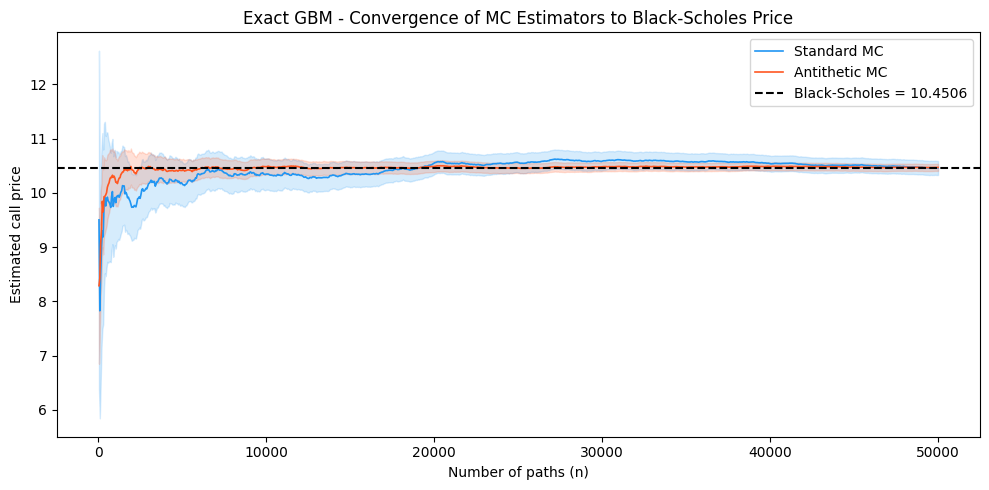

In [ ]:
"""
Exact GBM Monte Carlo Option Pricer with Antithetic Variates
============================================================
Prices European call and put options under GBM using the
closed-form exact GBM solution to simulate terminal stock prices.

The exact solution is:

    S(T) = S0 * exp((r - 0.5*sigma^2)*T + sigma*sqrt(T)*Z)

No time-stepping is involved — one standard Normal draw per path
is sufficient. There is zero discretisation error; the only source
of error is Monte Carlo sampling noise.

Usage
-----
    pricer = ExactGBMMC(S0=100, K=100, r=0.05, sigma=0.20, T=1, n=50_000)
    pricer.run()
    pricer.print_results()
    pricer.plot()
"""

import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


class ExactGBMMC:
    """
    European option pricer using the exact GBM solution with antithetic variates.

    Terminal stock prices are drawn directly from their true distribution —
    no time-stepping, no discretisation bias.

    Parameters
    ----------
    S0    : Initial stock price.
    K     : Strike price.
    r     : Risk-free rate (annualised, continuously compounded).
    sigma : Volatility (annualised).
    T     : Time to expiry in years.
    n     : Number of Monte Carlo paths.
    seed  : Random seed for reproducibility.
    """

    def __init__(self, S0, K, r, sigma, T, n, seed=42):
        if S0 <= 0 or K <= 0:
            raise ValueError("S0 and K must be positive.")
        if sigma <= 0 or T <= 0:
            raise ValueError("sigma and T must be positive.")

        self.S0    = S0
        self.K     = K
        self.r     = r
        self.sigma = sigma
        self.T     = T
        self.n     = n
        self.seed  = seed

        # Populated by .run()
        self.results         = None
        self.disc_payoff_std = None
        self.disc_payoff_av  = None
        self.disc_stock_av   = None

    # ------------------------------------------------------------------
    # Black-Scholes benchmarks
    # ------------------------------------------------------------------

    def _bs_call(self):
        """Closed-form Black-Scholes call price."""
        d1 = (np.log(self.S0 / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) \
             / (self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma * np.sqrt(self.T)
        return self.S0 * norm.cdf(d1) - self.K * np.exp(-self.r * self.T) * norm.cdf(d2)

    def _bs_put(self):
        """Black-Scholes put price via put-call parity."""
        return self._bs_call() - self.S0 + self.K * np.exp(-self.r * self.T)

    # ------------------------------------------------------------------
    # Simulation
    # ------------------------------------------------------------------

    def _simulate(self):
        """
        Simulate terminal GBM stock prices using the exact closed-form solution.

        By Ito's lemma, the SDE dS = r*S*dt + sigma*S*dW has the exact solution:

            S(T) = S0 * exp((r - 0.5*sigma^2)*T + sigma*sqrt(T)*Z),  Z ~ N(0,1)

        A single draw of Z per path is all that is needed — no time loop,
        no discretisation error. The antithetic path simply negates Z.

        Returns both standard and antithetic terminal prices, shape (2, n).
        """
        rng    = np.random.default_rng(self.seed)
        Z      = rng.standard_normal(self.n)               # (n,)

        drift  = (self.r - 0.5 * self.sigma**2) * self.T
        vol    = self.sigma * np.sqrt(self.T)

        S_std  = self.S0 * np.exp(drift + vol *  Z)        # (n,)
        S_anti = self.S0 * np.exp(drift + vol * -Z)        # (n,)

        return np.stack([S_std, S_anti])                    # (2, n)

    # ------------------------------------------------------------------
    # Payoffs
    # ------------------------------------------------------------------

    def _call_payoff(self, S):
        return np.maximum(S - self.K, 0.0)

    def _put_payoff(self, S):
        return np.maximum(self.K - S, 0.0)

    # ------------------------------------------------------------------
    # Confidence interval
    # ------------------------------------------------------------------

    def _mean_and_ci(self, samples, level=0.95):
        """Return (mean, lower, upper) using the Normal CLT approximation."""
        mu = float(np.mean(samples))
        se = float(np.std(samples, ddof=1)) / np.sqrt(len(samples))
        z  = norm.ppf(0.5 + level / 2)
        return mu, mu - z * se, mu + z * se

    # ------------------------------------------------------------------
    # Public interface
    # ------------------------------------------------------------------

    def run(self):
        """Run the full simulation and store all pricing + variance metrics."""
        discount = np.exp(-self.r * self.T)
        S        = self._simulate()              # (2, n)

        # Discounted payoffs for both path rows
        dp_call  = discount * self._call_payoff(S)   # (2, n)
        dp_put   = discount * self._put_payoff(S)    # (2, n)
        dp_stock = discount * S                      # (2, n)

        # Standard MC  — row 0 only
        self.disc_payoff_std = dp_call[0]

        # Antithetic estimator — average each pair before averaging over n
        self.disc_payoff_av = 0.5 * (dp_call[0]  + dp_call[1])
        self.disc_stock_av  = 0.5 * (dp_stock[0] + dp_stock[1])
        disc_put_av         = 0.5 * (dp_put[0]   + dp_put[1])

        # Black-Scholes
        bs_call = self._bs_call()
        bs_put  = self._bs_put()

        # Prices + CIs
        p_std, ci_std_lo, ci_std_hi = self._mean_and_ci(self.disc_payoff_std)
        p_av,  ci_av_lo,  ci_av_hi  = self._mean_and_ci(self.disc_payoff_av)
        p_put, ci_put_lo, ci_put_hi = self._mean_and_ci(disc_put_av)

        # Variance helpers
        def var_est(x):
            return float(np.var(x, ddof=1)) / self.n

        def corr(a, b):
            return float(np.corrcoef(a, b)[0, 1])

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            payoff_ratio = var_est(self.disc_payoff_std) / var_est(self.disc_payoff_av)
            stock_ratio  = var_est(dp_stock[0]) / var_est(self.disc_stock_av)

        self.results = {
            # Call
            "Call — Standard MC":               p_std,
            "Call — Standard MC 95% CI lo":     ci_std_lo,
            "Call — Standard MC 95% CI hi":     ci_std_hi,
            "Call — Antithetic MC":             p_av,
            "Call — Antithetic MC 95% CI lo":   ci_av_lo,
            "Call — Antithetic MC 95% CI hi":   ci_av_hi,
            "Call — Black-Scholes":             bs_call,
            "Call abs error — Standard MC":     abs(p_std - bs_call),
            "Call abs error — Antithetic MC":   abs(p_av  - bs_call),
            # Put
            "Put — Antithetic MC":              p_put,
            "Put — Antithetic MC 95% CI lo":    ci_put_lo,
            "Put — Antithetic MC 95% CI hi":    ci_put_hi,
            "Put — Black-Scholes":              bs_put,
            "Put abs error — Antithetic MC":    abs(p_put - bs_put),
            # Variance reduction
            "Var(estimator) — Standard MC":     var_est(self.disc_payoff_std),
            "Var(estimator) — Antithetic MC":   var_est(self.disc_payoff_av),
            "Payoff variance reduction ratio":  payoff_ratio,
            "Corr(payoff+, payoff-)":           corr(dp_call[0], dp_call[1]),
            # Martingale check
            "E[disc. stock] — Standard MC":     float(np.mean(dp_stock[0])),
            "E[disc. stock] — Antithetic MC":   float(np.mean(self.disc_stock_av)),
            "Stock variance reduction ratio":   stock_ratio,
            "Corr(stock+, stock-)":             corr(dp_stock[0], dp_stock[1]),
        }
        return self

    def print_results(self):
        """Print results grouped into labelled sections."""
        if self.results is None:
            raise RuntimeError("Call .run() first.")

        sections = [
            ("CALL PRICING", [
                "Call — Standard MC",
                "Call — Standard MC 95% CI lo",
                "Call — Standard MC 95% CI hi",
                "Call — Antithetic MC",
                "Call — Antithetic MC 95% CI lo",
                "Call — Antithetic MC 95% CI hi",
                "Call — Black-Scholes",
                "Call abs error — Standard MC",
                "Call abs error — Antithetic MC",
            ]),
            ("PUT PRICING", [
                "Put — Antithetic MC",
                "Put — Antithetic MC 95% CI lo",
                "Put — Antithetic MC 95% CI hi",
                "Put — Black-Scholes",
                "Put abs error — Antithetic MC",
            ]),
            ("VARIANCE REDUCTION", [
                "Var(estimator) — Standard MC",
                "Var(estimator) — Antithetic MC",
                "Payoff variance reduction ratio",
                "Corr(payoff+, payoff-)",
            ]),
            ("MARTINGALE CHECK  (E[e^{-rT} S_T] should equal S0)", [
                "E[disc. stock] — Standard MC",
                "E[disc. stock] — Antithetic MC",
                "Stock variance reduction ratio",
                "Corr(stock+, stock-)",
            ]),
        ]

        col_w = 44
        for title, keys in sections:
            print(f"\n{'─' * 62}")
            print(f"  {title}")
            print(f"{'─' * 62}")
            for k in keys:
                print(f"  {k:<{col_w}}  {self.results[k]:>12.6f}")
        print(f"\n{'─' * 62}\n")

    def plot(self):
        """Produce convergence + distribution plots."""
        if self.results is None:
            raise RuntimeError("Call .run() first.")

        self._plot_convergence()
        #self._plot_histogram(
        #    self.disc_payoff_av,
        #    vlines=[
        #        (self.results["Call — Antithetic MC"],
        #         f"Antithetic MC = {self.results['Call — Antithetic MC']:.4f}", "-"),
        #        (self.results["Call — Black-Scholes"],
        #         f"Black-Scholes = {self.results['Call — Black-Scholes']:.4f}", "--"),
        #    ],
        #    xlabel="Discounted terminal payoff",
        #    title="Antithetic MC: Discounted Call Payoff Distribution",
        #)
        #self._plot_histogram(
        #    self.disc_stock_av,
        #    vlines=[
        #        (self.results["E[disc. stock] — Antithetic MC"],
        #         f"MC mean = {self.results['E[disc. stock] — Antithetic MC']:.4f}", "-"),
        #        (self.S0, f"S₀ = {self.S0:.4f}  (martingale target)", "--"),
        #    ],
        #    xlabel="Discounted terminal stock value",
        #    title="Antithetic MC: Discounted Stock Value Distribution",
        #)

    # ------------------------------------------------------------------
    # Private plot helpers
    # ------------------------------------------------------------------

    def _plot_convergence(self):
        bs  = self.results["Call — Black-Scholes"]
        ns  = np.arange(1, self.n + 1)
        z95 = norm.ppf(0.975)

        def running_stats(samples):
            cum    = np.cumsum(samples)
            mean   = cum / ns
            cum_sq = np.cumsum(samples ** 2)
            with np.errstate(invalid="ignore"):
                var = np.where(ns > 1, (cum_sq - cum**2 / ns) / (ns - 1), 0.0)
            se = np.sqrt(np.maximum(var, 0.0) / ns)
            return mean, mean - z95 * se, mean + z95 * se

        step = max(1, self.n // 1000)
        idx  = np.arange(step - 1, self.n, step)

        ms, ls, hs = running_stats(self.disc_payoff_std)
        ma, la, ha = running_stats(self.disc_payoff_av)

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(ns[idx], ms[idx], color="#2196F3", linewidth=1.2, label="Standard MC")
        ax.fill_between(ns[idx], ls[idx], hs[idx], color="#2196F3", alpha=0.18)
        ax.plot(ns[idx], ma[idx], color="#FF5722", linewidth=1.2, label="Antithetic MC")
        ax.fill_between(ns[idx], la[idx], ha[idx], color="#FF5722", alpha=0.18)
        ax.axhline(bs, color="black", linestyle="--", linewidth=1.5,
                   label=f"Black-Scholes = {bs:.4f}")
        ax.set_xlabel("Number of paths (n)")
        ax.set_ylabel("Estimated call price")
        ax.set_title("Exact GBM - Convergence of MC Estimators to Black-Scholes Price")
        ax.legend()
        plt.tight_layout()
        plt.show()

    def _plot_histogram(self, data, vlines, xlabel, title):
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.hist(data, bins=60, alpha=0.75, edgecolor="black", linewidth=0.4)
        for value, label, style in vlines:
            ax.axvline(value, linewidth=2, linestyle=style, label=label)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Frequency")
        ax.set_title(title)
        ax.legend()
        plt.tight_layout()
        plt.show()


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    pricer = ExactGBMMC(
        S0=100, K=100, r=0.05, sigma=0.20,
        T=1, n=50_000, seed=42,
    )
    pricer.run()
    pricer.print_results()
    pricer.plot()

The results confirm that the antithetic variates technique is highly effective, delivering a substantial reduction in estimator variance relative to standard Monte Carlo simulation. This improvement stems from the strong negative correlation induced between paired sample paths, which directly reduces the variance of the averaged estimator. Moreover, the method is computationally efficient: each pair of antithetic paths is generated from a single set of random draws, effectively increasing the information extracted per simulation without additional random number generation cost.

Across the numerical schemes considered, the Euler method exhibited the lowest variance, reflecting its strong variance reduction under this framework. However, in terms of accuracy, the exact Geometric Brownian Motion (GBM) formulation produced option prices closest to the Black–Scholes model benchmark. This highlights the trade-off between numerical approximation error and variance reduction: while discretization schemes may benefit more from variance reduction techniques, the exact GBM solution remains superior in pricing accuracy due to the absence of time-discretization error.

A key observation from the variance reduction analysis is the difference in effectiveness of antithetic variates when applied to the discounted stock versus the option payoff. For the discounted stock, the transformation from the underlying Gaussian variable is smooth and monotonic, preserving a near-perfect negative symmetry between antithetic pairs. As a result, the correlation between paired samples is close to −1, leading to a very significant reduction in variance.

In contrast, the option payoff introduces a strong nonlinearity through the function $max(S_{T}−K,0)$. This payoff structure truncates negative outcomes at zero, breaking the symmetry between antithetic paths. In many cases, one path in the pair may produce a positive payoff while the other is zero, reducing the strength of the negative correlation. Consequently, although variance reduction is still achieved, it is substantially less pronounced than in the case of the discounted stock. This highlights the importance of payoff structure in determining the efficiency of variance reduction techniques.

# Real example for Equity pricer with Bloomberg data

New we will compare the three Monte Carlo methods pricing a Vanilla Equity option for Apple stock. The value obtained is compared with the Black-Scholes price in a Bloomberg terminal, using real-data as of April 24, 2026.


In [ ]:
import numpy as np


class EquityOptionMonteCarloPricer:
    def __init__(
        self,
        S0,
        K,
        r,
        q,
        sigma,
        T,
        n,
        m=252,
        option_type="call",
        seed=42
    ):
        self.S0 = float(S0)
        self.K = float(K)
        self.r = float(r)
        self.q = float(q)
        self.sigma = float(sigma)
        self.T = float(T)
        self.n = int(n)
        self.m = int(m)
        self.dt = self.T / self.m
        self.option_type = option_type.lower()
        self.seed = seed

        self.drift = self.r - self.q

    # ---------------------------
    # Payoff
    # ---------------------------
    def payoff(self, S):
        if self.option_type == "call":
            return np.maximum(S - self.K, 0)
        elif self.option_type == "put":
            return np.maximum(self.K - S, 0)
        else:
            raise ValueError("option_type must be 'call' or 'put'")

    def discount(self, payoff):
        return np.exp(-self.r * self.T) * payoff

    # ---------------------------
    # Simulation methods
    # ---------------------------
    def simulate_euler_antithetic(self):
        np.random.seed(self.seed)

        S_plus = np.full(self.n, self.S0, dtype=float)
        S_minus = np.full(self.n, self.S0, dtype=float)

        for _ in range(self.m):
            z = np.random.randn(self.n)

            S_plus *= (
                1
                + self.drift * self.dt
                + self.sigma * np.sqrt(self.dt) * z
            )

            S_minus *= (
                1
                + self.drift * self.dt
                - self.sigma * np.sqrt(self.dt) * z
            )

        return S_plus, S_minus

    def simulate_milstein_antithetic(self):
        np.random.seed(self.seed)

        S_plus = np.full(self.n, self.S0, dtype=float)
        S_minus = np.full(self.n, self.S0, dtype=float)

        for _ in range(self.m):
            z = np.random.randn(self.n)

            dW = np.sqrt(self.dt) * z

            S_plus *= (
                1
                + self.drift * self.dt
                + self.sigma * dW
                + 0.5 * self.sigma**2 * (dW**2 - self.dt)
            )

            S_minus *= (
                1
                + self.drift * self.dt
                - self.sigma * dW
                + 0.5 * self.sigma**2 * (dW**2 - self.dt)
            )

        return S_plus, S_minus

    def simulate_exact_gbm_antithetic(self):
        np.random.seed(self.seed)

        z = np.random.randn(self.n)

        S_plus = self.S0 * np.exp(
            (self.drift - 0.5 * self.sigma**2) * self.T
            + self.sigma * np.sqrt(self.T) * z
        )

        S_minus = self.S0 * np.exp(
            (self.drift - 0.5 * self.sigma**2) * self.T
            - self.sigma * np.sqrt(self.T) * z
        )

        return S_plus, S_minus

    # ---------------------------
    # Pricing
    # ---------------------------
    def price(self, method="gbm"):
        method = method.lower()

        if method == "euler":
            S_plus, S_minus = self.simulate_euler_antithetic()
        elif method == "milstein":
            S_plus, S_minus = self.simulate_milstein_antithetic()
        elif method in ["gbm", "exact", "exact_gbm"]:
            S_plus, S_minus = self.simulate_exact_gbm_antithetic()
        else:
            raise ValueError("method must be 'euler', 'milstein', or 'gbm'")

        # ---------------------------
        # Forward (MC)
        # ---------------------------
        S_avg = 0.5 * (S_plus + S_minus)
        forward_mc = np.mean(S_avg)

        # Theoretical forward
        forward_theoretical = self.S0 * np.exp((self.r - self.q) * self.T)

        # ---------------------------
        # Payoff
        # ---------------------------
        payoff_plus = self.payoff(S_plus)
        payoff_minus = self.payoff(S_minus)

        Y_plus = self.discount(payoff_plus)
        Y_minus = self.discount(payoff_minus)

        Y = 0.5 * (Y_plus + Y_minus)

        price = np.mean(Y)

        return {
            "Method": method,
            "Option Type": self.option_type,
            "Price": price,
            "Forward": forward_mc,
        }

    def price_all_methods(self):
        return {
            method: self.price(method)
            for method in ["euler", "milstein", "gbm"]
        }



In [ ]:
# Bloomberg Example for Apple stock as of April 24, 2026
pricer = EquityOptionMonteCarloPricer(
    S0=271.01,
    K=272,
    r=0.03667,
    q=0.004,
    sigma=0.26161,
    T=(91/365),
    n=500000,
    m=252,
    option_type="call",
    seed=42
)

results = pricer.price_all_methods()

for method, output in results.items():
    print(f"\n--- {method.upper()} ---")
    for k, v in output.items():
        if isinstance(v, float):
            print(f"{k}: {v:.8f}")
        else:
            print(f"{k}: {v}")


--- EULER ---
Method: euler
Option Type: call
Price: 14.66701254
Forward: 273.22050662

--- MILSTEIN ---
Method: milstein
Option Type: call
Price: 14.66660727
Forward: 273.22089510

--- GBM ---
Method: gbm
Option Type: call
Price: 14.69381463
Forward: 273.22859779


As we can see, three MC are very close to the exact Black-Scholes formula showed in Bloomberg. The closed framwork was the Milestein scheme.  Numerical rounding for the interest rate, volatility leds to such difference.

![My Image](Vanilla.png)

# Digital Options

Digital or Binary options are a Exotic typy of options. For a digital call - cash or nothing the payyoff is the following:

$$
g(S_T) =
\begin{cases}
1 \cdot N, & \text{if } S_T > K \\
0, & \text{otherwise}
\end{cases}
$$

where $N$ is the notional amount of the payout.

Saying in mathematical formulas the payoff and the option value are given by:

$$
\text{Payoff} = N \cdot \mathbf{1}_{\{S_T > K\}}$$

$$V_0 = e^{-rT} \cdot N \cdot \mathbb{Q}(S_T > K)$$



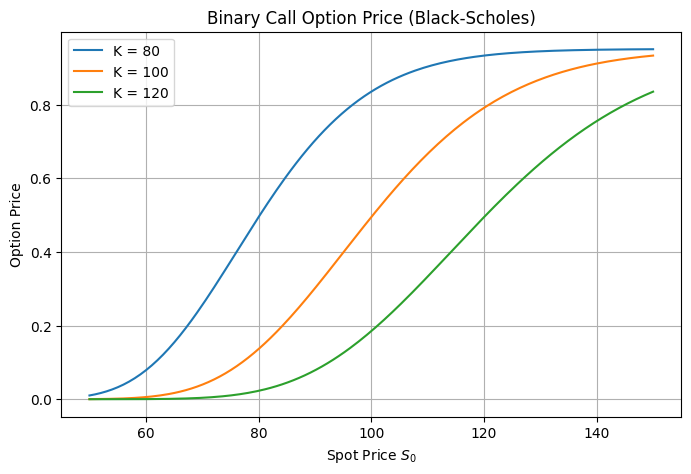

In [ ]:
# Digital call payoff diagram

# Parameters
r = 0.05
q = 0.02
sigma = 0.2
T = 1.0

# Spot range
S0 = np.linspace(50, 150, 200)

# Different strikes
strikes = [80, 100, 120]

def digital_call_price(S, K):
    d2 = (
        np.log(S / K)
        + (r - q - 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    return np.exp(-r * T) * norm.cdf(d2)

# Plot
plt.figure(figsize=(8, 5))

for K in strikes:
    price = digital_call_price(S0, K)
    plt.plot(S0, price, label=f"K = {K}")

plt.title("Binary Call Option Price (Black-Scholes)")
plt.xlabel("Spot Price $S_0$")
plt.ylabel("Option Price")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import numpy as np


class DigitalOptionMonteCarloPricer:
    def __init__(
        self,
        S0,
        K,
        r,
        q,
        sigma,
        T,
        n,
        notional=1.0,
        m=252,
        option_type="call",
        seed=42
    ):
        self.S0 = float(S0)
        self.K = float(K)
        self.r = float(r)
        self.q = float(q)
        self.sigma = float(sigma)
        self.T = float(T)
        self.n = int(n)
        self.m = int(m)
        self.dt = self.T / self.m
        self.option_type = option_type.lower()
        self.seed = seed
        self.notional = float(notional)

        self.drift = self.r - self.q

    # ---------------------------
    # Digital payoff
    # ---------------------------
    def payoff(self, S):
        if self.option_type == "call":
            indicator = (S > self.K)
        elif self.option_type == "put":
            indicator = (S < self.K)
        else:
            raise ValueError("option_type must be 'call' or 'put'")

        return self.notional * indicator.astype(float)

    def discount(self, payoff):
        return np.exp(-self.r * self.T) * payoff

    # ---------------------------
    # Simulation methods
    # ---------------------------
    def simulate_euler_antithetic(self):
        np.random.seed(self.seed)

        S_plus = np.full(self.n, self.S0, dtype=float)
        S_minus = np.full(self.n, self.S0, dtype=float)

        for _ in range(self.m):
            z = np.random.randn(self.n)

            S_plus *= (
                1 + self.drift * self.dt + self.sigma * np.sqrt(self.dt) * z
            )

            S_minus *= (
                1 + self.drift * self.dt - self.sigma * np.sqrt(self.dt) * z
            )

        return S_plus, S_minus

    def simulate_milstein_antithetic(self):
        np.random.seed(self.seed)

        S_plus = np.full(self.n, self.S0, dtype=float)
        S_minus = np.full(self.n, self.S0, dtype=float)

        for _ in range(self.m):
            z = np.random.randn(self.n)
            dW = np.sqrt(self.dt) * z

            S_plus *= (
                1
                + self.drift * self.dt
                + self.sigma * dW
                + 0.5 * self.sigma**2 * (dW**2 - self.dt)
            )

            S_minus *= (
                1
                + self.drift * self.dt
                - self.sigma * dW
                + 0.5 * self.sigma**2 * (dW**2 - self.dt)
            )

        return S_plus, S_minus

    def simulate_exact_gbm_antithetic(self):
        np.random.seed(self.seed)

        z = np.random.randn(self.n)

        S_plus = self.S0 * np.exp(
            (self.drift - 0.5 * self.sigma**2) * self.T
            + self.sigma * np.sqrt(self.T) * z
        )

        S_minus = self.S0 * np.exp(
            (self.drift - 0.5 * self.sigma**2) * self.T
            - self.sigma * np.sqrt(self.T) * z
        )

        return S_plus, S_minus

    # ---------------------------
    # Pricing (FIXED INDENTATION)
    # ---------------------------
    def price(self, method="gbm"):
        method = method.lower()

        if method == "euler":
            S_plus, S_minus = self.simulate_euler_antithetic()
        elif method == "milstein":
            S_plus, S_minus = self.simulate_milstein_antithetic()
        elif method in ["gbm", "exact"]:
            S_plus, S_minus = self.simulate_exact_gbm_antithetic()
        else:
            raise ValueError("Invalid method")

        # Forward (average ST)
        S_avg = 0.5 * (S_plus + S_minus)
        forward_mc = np.mean(S_avg)

        # Digital payoff
        payoff_plus = self.payoff(S_plus)
        payoff_minus = self.payoff(S_minus)

        Y_plus = self.discount(payoff_plus)
        Y_minus = self.discount(payoff_minus)

        Y = 0.5 * (Y_plus + Y_minus)

        price = np.mean(Y)

        return {
            "Method": method,
            "Option Type": self.option_type,
            "Price": price,
            "Forward": forward_mc
        }

    def price_all_methods(self):
        return {
            method: self.price(method)
            for method in ["euler", "milstein", "gbm"]
        }

In [ ]:
pricer = DigitalOptionMonteCarloPricer(
    S0=271.01,
    K=272,
    r=0.03667,
    q=0.004,
    sigma=0.26161,
    T=(91/365),
    n=500000,
    notional=100.0,   # pays 10 if ITM
    option_type="call"
)

results = pricer.price_all_methods()

for method, output in results.items():
    print(f"\n--- {method.upper()} ---")
    for k, v in output.items():
        if isinstance(v, float):
            print(f"{k}: {v:.8f}")
        else:
            print(f"{k}: {v}")


--- EULER ---
Method: euler
Option Type: call
Price: 48.31545622
Forward: 273.22050662

--- MILSTEIN ---
Method: milstein
Option Type: call
Price: 48.30277271
Forward: 273.22089510

--- GBM ---
Method: gbm
Option Type: call
Price: 48.31714075
Forward: 273.22859779


As we can see, three MC are very close to the exact Black-Scholes formula showed in Bloomberg again.
The closed framwork was the Milestein scheme again.
Numerical rounding for the interest rate, volatility leds to such difference.
![My Image](digital.png)

# Conclusions

This study demonstrates the effectiveness of Monte Carlo methods for pricing options under the Black–Scholes framework, highlighting both numerical accuracy and computational considerations. The Euler–Maruyama and Milstein schemes provide reliable approximations of the underlying stochastic dynamics, with Milstein offering a marginal improvement due to its higher-order correction. However, the exact Geometric Brownian Motion formulation consistently delivers the most accurate results, as it eliminates discretization error entirely.

The sensitivity analysis confirms that all three approaches capture the correct economic relationships between option prices and model parameters, with discrepancies remaining negligible across a wide range of inputs. This reinforces the robustness of these numerical methods in practical applications.

The incorporation of antithetic variates significantly enhances simulation efficiency by reducing estimator variance through induced negative correlation. While the variance reduction is particularly pronounced for the discounted stock—where near-perfect negative correlation can be achieved—it is more moderate for option payoffs due to their nonlinear and truncated structure. Nevertheless, the method provides a meaningful improvement in precision without additional computational cost.

Overall, the results highlight a fundamental trade-off: while exact analytical solutions offer superior accuracy when available, numerical schemes combined with variance reduction techniques provide a flexible and efficient framework for more complex settings where closed-form solutions do not exist.

In my professional experience, I wil, tackle vanillas an digital with Black-Scholes without any Monte Carlo framework. I reckon MC is vere relevant in path-depedent option , specilla for structured product of convertible bonds, or mortgage backed securities modelling, with very compex clauses involving in the product, where MC techcniques are ideal. Moreover, where early excersise could be combine with Least/squared Monte Calro Technicque.......

# Bibliography

Jäckel, P. (2002) Monte Carlo Methods in Finance. Chichester: Wiley.

Hilpisch, Y. (2019) Python for Finance: Mastering Data-Driven Finance. 2nd edn. Sebastopol, CA: O’Reilly Media.

Willmott, P. (2006) Paul Wilmott on Quantitative Finance. Volume 1. 2nd edn. Chichester: Wiley.

Willmott, P. (2006) Paul Wilmott on Quantitative Finance. Volume 2. 2nd edn. Chichester: Wiley.